In [1]:
from google.colab import files

uploaded = files.upload()


Saving auth.log to auth.log
Saving ssh_attack.pcap to ssh_attack.pcap


In [2]:
!pip install scapy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 35.1 MB/s eta 0:00:00


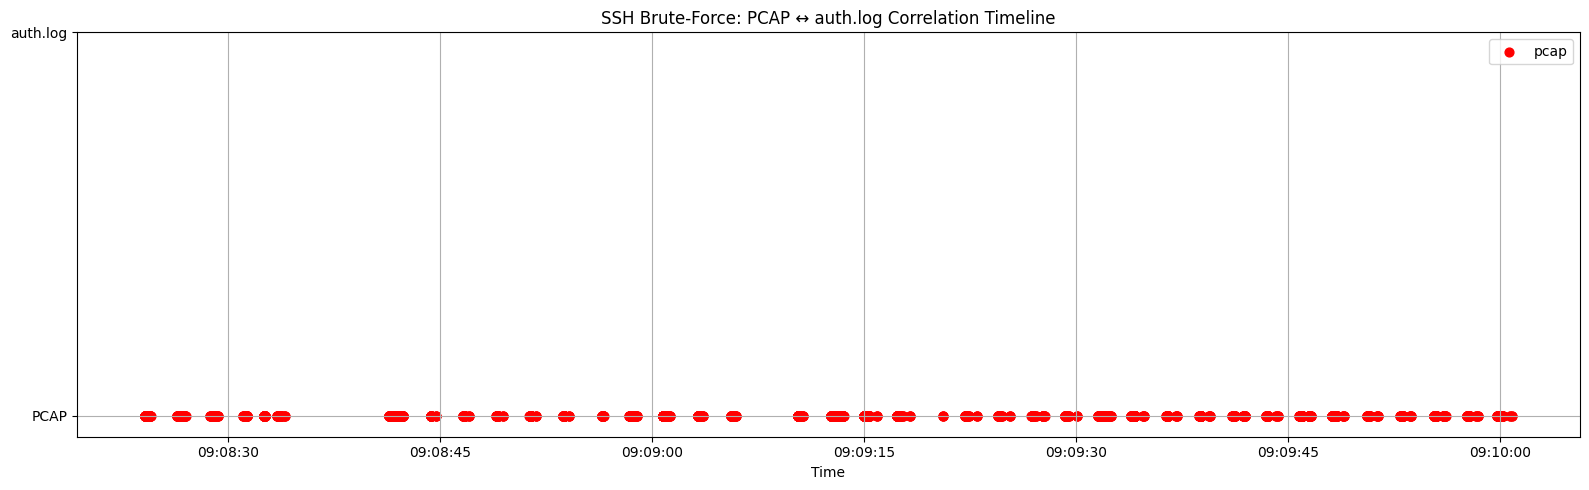

,timestamp,event,source
0,2025-12-24 09:08:24.166886,"b""\x08\x00'c\xb0\x05\x00\x00"":39036 → 192.168....",pcap
1,2025-12-24 09:08:24.173233,"b""\x08\x00'\x9a\xf9^\x00\x00"":22 → 192.168.56....",pcap
2,2025-12-24 09:08:24.173684,"b""\x08\x00'c\xb0\x05\x00\x00"":39050 → 192.168....",pcap
3,2025-12-24 09:08:24.173774,"b""\x08\x00'\x9a\xf9^\x00\x00"":22 → 192.168.56....",pcap
4,2025-12-24 09:08:24.177113,"b""\x08\x00'\x9a\xf9^\x00\x00"":22 → 192.168.56....",pcap


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('event').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['timestamp']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'timestamp'}, axis=1)
              .sort_values('timestamp', ascending=True))
  xs = counted['timestamp']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('timestamp', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('event')):
  _plot_series(series, series_name, i)
  fig.legend(title='event', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('timestamp')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('index', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('event')):
  _plot_series(series, series_name, i)
  fig.legend(title='event', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['timestamp']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'timestamp'}, axis=1)
              .sort_values('timestamp', ascending=True))
  xs = counted['timestamp']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_4.sort_values('timestamp', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('event')):
  _plot_series(series, series_name, i)
  fig.legend(title='event', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('timestamp')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_5['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_6['event'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_6, x='index', y='event', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scapy.all import rdpcap
import datetime
import re

# --------------------------
# 1. Parse auth.log (Ubuntu format)
# Example:
# Dec 23 07:50:18 cyberserver sshd[1234]: Failed password for invalid user ubuntu from 192.168.56.102 port 56954 ssh2
# --------------------------
def parse_auth_log(log_file):
    log_entries = []
    year = datetime.datetime.now().year

    log_pattern = re.compile(
        r"(\w{3}\s+\d+\s+\d{2}:\d{2}:\d{2}).*sshd.*: (.+)"
    )

    with open(log_file, "r") as f:
        for line in f:
            match = log_pattern.search(line)
            if match:
                timestamp_str = f"{year} {match.group(1)}"
                timestamp = datetime.datetime.strptime(timestamp_str, "%Y %b %d %H:%M:%S")
                message = match.group(2)
                log_entries.append({
                    "timestamp": timestamp,
                    "event": message,
                    "source": "auth.log"
                })

    return pd.DataFrame(log_entries)

# --------------------------
# 2. Parse PCAP
# --------------------------
def parse_pcap(pcap_file):
    packets = rdpcap(pcap_file)
    pcap_entries = []

    for pkt in packets:
        if pkt.haslayer("TCP"):
            ts = datetime.datetime.fromtimestamp(float(pkt.time))
            src = pkt[0].src
            dst = pkt[0].dst
            sport = pkt["TCP"].sport
            dport = pkt["TCP"].dport

            event = f"{src}:{sport} → {dst}:{dport}"
            pcap_entries.append({
                "timestamp": ts,
                "event": event,
                "source": "pcap"
            })

    return pd.DataFrame(pcap_entries)

# --------------------------
# 3. Correlate events
# --------------------------
def correlate_events(log_df, pcap_df):
    combined = pd.concat([log_df, pcap_df])
    combined.sort_values("timestamp", inplace=True)
    combined.reset_index(drop=True, inplace=True)
    return combined

# --------------------------
# 4. Plot timeline
# --------------------------
def plot_timeline(df):
    plt.figure(figsize=(16, 5))

    y_map = {"auth.log": 1, "pcap": 0}
    colors = {"auth.log": "blue", "pcap": "red"}

    for source in df["source"].unique():
        subset = df[df["source"] == source]
        plt.scatter(
            subset["timestamp"],
            [y_map[source]] * len(subset),
            label=source,
            color=colors[source],
            s=40
        )

    plt.yticks([0, 1], ["PCAP", "auth.log"])
    plt.xlabel("Time")
    plt.title("SSH Brute-Force: PCAP ↔ auth.log Correlation Timeline")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --------------------------
# 5. Run everything
# --------------------------
log_df = parse_auth_log("/content/auth.log")
pcap_df = parse_pcap("/content/ssh_attack.pcap")

combined_df = correlate_events(log_df, pcap_df)
plot_timeline(combined_df)

combined_df.head()


In [4]:
import os
os.listdir("/content")


['.config', 'ssh_attack.pcap', 'auth.log', 'sample_data']